# Задание
• На основе датасета, который был использован вами для промежуточной аттестации (или другого):

• Выберите вещественную переменную в качестве таргета и несколько объясняющих переменных

• Постройте точечные диаграммы (scatterplots) для таргета и каждой фичи, опишите форму взаимосвязи между переменными

• Разделите датасет на обучающую и тестовую выборки

• Сделайте масштабирование объясняющих переменных

• Обучите модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающейвыборке

• Сделайте предсказания целевой переменной для тестовой выборки

• Рассчитайте метрики качества

• Выберите спецификацию модели с наилучшим качеством

• Сделайте выводы относительно полученной модели и ее качества

• Разместите блокнот в GitHub и прикрепите ссылку на блокнот в удаленном репозитории


# Подготовка


## Данные

Данные были сформированы из MSSQL Server базы компании и выгружены в Excel для дальнейшей обработки. В качестве источника представлены два набора данных:
* empl_1.xlsx - список сотрудников по месячно, (date - месяц и год, qnt - количество сотрудников, имеющих доступ к компьютерам, qnt_total - общее количество сотрудников)
* data_1.xlsx - список покупок (я удалил конкретные наименования товаров, оставил только категории( date - месяц и год, category - категория, qnt - количество)

## Описание задачи

В качестве задачи я решил взять предсказание затрат на Мониторы в следующем месяце (взял только одну категорию товаров, для примера).


## Импорт пакетов

In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Загрузка данных

In [111]:
employeeRaw = (pd
                .read_excel("empl_1.xlsx")
                .sort_values('date')
)
dataRaw = (pd
           .read_excel("data_1.xlsx")
           .sort_values('date')
)
print("Сотрудники: ", employeeRaw.shape)
print("Покупки: ", dataRaw.shape)

print(dataRaw.groupby("category").nunique().index.tolist())

Сотрудники:  (129, 3)
Покупки:  (4728, 4)
['Батарейка', 'Блок питания', 'Веб-камера', 'Видеокарта', 'Жесткий диск', 'Запчасти для компьютера', 'Запчасти для принтера', 'Кабель/Адаптер', 'Картридж', 'Клавиатура', 'Коммутатор/Свитч/Роутер', 'Компьютер/Ноутбук', 'Корпус компьютерный', 'МФУ', 'Материнская плата', 'Монитор', 'Мышь', 'Наушники', 'ОЗУ', 'Принтер', 'Программное обеспечение', 'Процессор', 'Прочее', 'Сетевое оборудование', 'Смартфон/Мобильное устройство', 'Телевизор', 'Тонер/Чернила', 'Флеш накопитель']


In [112]:
dataRaw.groupby("category").agg(recCount = ("date", "count")).sort_values("recCount", ascending = False)

,recCount
category,
Запчасти для принтера,982
Картридж,801
Прочее,603
Тонер/Чернила,330
Кабель/Адаптер,303
Жесткий диск,222
Мышь,172
Запчасти для компьютера,158
Компьютер/Ноутбук,143


## Подготавливаем данные

In [113]:
## Сотрудники
employee = (
    employeeRaw
    .assign(delta = lambda x: x["qty"] - x["qty"].shift(1))
    .assign(year = lambda x: x["date"].dt.year)
    .assign(month = lambda x: x["date"].dt.month)
    .assign(quarter = lambda x: x["date"].dt.quarter)
    .fillna(0)
)

print(employee)

          date  total_qty  qty  delta  year  month  quarter
0   2016-01-01        842  484    0.0  2016      1        1
1   2016-02-01        840  483   -1.0  2016      2        1
2   2016-03-01        841  487    4.0  2016      3        1
3   2016-04-01        841  489    2.0  2016      4        2
4   2016-05-01        838  489    0.0  2016      5        2
..         ...        ...  ...    ...   ...    ...      ...
124 2026-05-01        997  577    5.0  2026      5        2
125 2026-06-01        997  576   -1.0  2026      6        2
126 2026-07-01        998  578    2.0  2026      7        3
127 2026-08-01        996  577   -1.0  2026      8        3
128 2026-09-01        996  577    0.0  2026      9        3

[129 rows x 7 columns]


In [114]:
## Покупки
dataMonitor = (
    dataRaw[dataRaw["category"] == "Монитор"]
    #dataRaw[dataRaw["category"] == "Запчасти для принтера"] # Самая большая выборка
    #dataRaw[dataRaw["category"] == "Картридж"]
    #dataRaw[dataRaw["category"] == "Компьютер/Ноутбук"]
    .groupby("date")
    .agg(
        data_qty = ("qty", "sum"),
        sum = ("sum", "sum")
    )
    .merge(employee, how="right", on="date")
    # заполняем пропуски методом средней интерполяции
    .interpolate(method='linear')
    .assign(
        # средняя цена
        avg_price = lambda x: x["sum"] / x["data_qty"],
        # сумма за прошлый месяц
        sum_lag1 = lambda x: x["sum"].shift(1),
        # сумма за 2 месяца назад
        sum_lag2 = lambda x: x["sum"].shift(2),
        # сумма за тот же месяц год назад (для проверки временной периодичнности)
        sum_lag12 = lambda x: x["sum"].shift(12),
        # средняя за последние 3 месяца
        sum_avg3 = lambda x: x["sum"].rolling(window=3, min_periods=1).mean(),
        # средняя за последние пол года
        sum_avg6 = lambda x: x["sum"].rolling(window=6, min_periods=1).mean(),
        # средняя за последний год
        sum_avg12 = lambda x: x["sum"].rolling(window=12, min_periods=1).mean(),
        # дельта по сравнению с предыдущем месяцем
        sum_delta_lag1 = lambda x: x["sum"] - x["sum_lag1"],
        # дельта по сравнению с предыдущим годом
        sum_delta_lag12 = lambda x: x["sum"] - x["sum_lag12"],
        # дельта по сравнению со средним за год
        sum_delta_avg12 = lambda x: x["sum"] - x["sum_avg12"],
    )
    .assign(
        # средняя цена за предыдущий месяц
        avg_price_lag1 = lambda x: x["avg_price"].shift(1),
    )
    # заполняем пропуски последующие
    .ffill()
    # заполняем пропуски предыдущие
    .bfill()
    # заполняем пустоты
    .fillna(0)
)

print(dataMonitor.head(5))

        date  data_qty      sum  total_qty  qty  delta  year  month  quarter  \
0 2016-01-01       1.0  9016.95        842  484    0.0  2016      1        1   
1 2016-02-01       1.0  9016.95        840  483   -1.0  2016      2        1   
2 2016-03-01       1.0  9016.95        841  487    4.0  2016      3        1   
3 2016-04-01       1.0  9016.95        841  489    2.0  2016      4        2   
4 2016-05-01       1.0  9016.95        838  489    0.0  2016      5        2   

   avg_price  sum_lag1  sum_lag2  sum_lag12  sum_avg3  sum_avg6  sum_avg12  \
0    9016.95   9016.95   9016.95    9016.95   9016.95   9016.95    9016.95   
1    9016.95   9016.95   9016.95    9016.95   9016.95   9016.95    9016.95   
2    9016.95   9016.95   9016.95    9016.95   9016.95   9016.95    9016.95   
3    9016.95   9016.95   9016.95    9016.95   9016.95   9016.95    9016.95   
4    9016.95   9016.95   9016.95    9016.95   9016.95   9016.95    9016.95   

   sum_delta_lag1  sum_delta_lag12  sum_delta_avg1

## Исследование

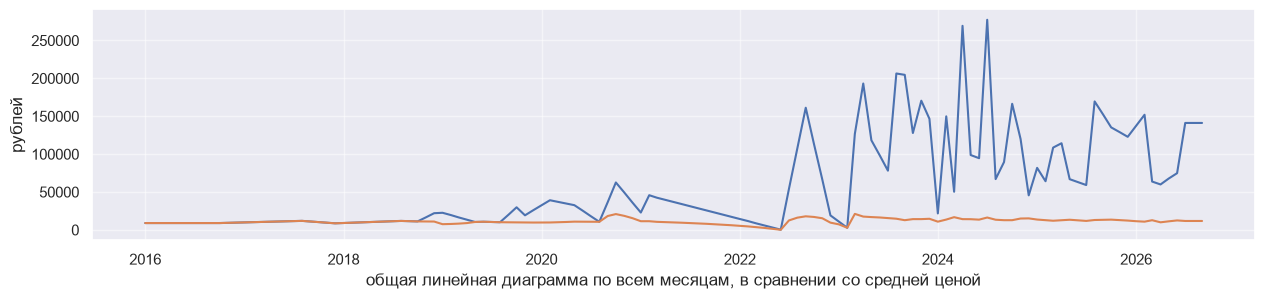

In [115]:
# общая линейная диаграмма по всем месяцам, чтобы видеть динамику, в сравнении со средней ценой
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="sum")
sns.lineplot(data=dataMonitor, x="date", y="avg_price")
plt.xlabel("общая линейная диаграмма по всем месяцам, в сравнении со средней ценой")
plt.ylabel("рублей")
plt.show()

Видно, что основной рост закупок происходит после 2023 года, и закупки носят не постоянный характер и не зависят от средней цены, это говорит о том, что компания активно развивалась с 2023 по 2025 года

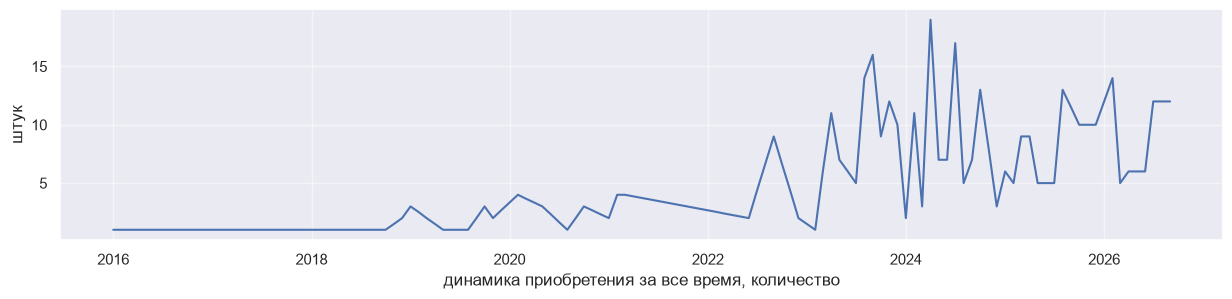

In [116]:
# динамика приобретения за все время, количество
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="data_qty")
plt.xlabel("динамика приобретения за все время, количество")
plt.ylabel("штук")
plt.show()

Из даннного графика можно также выявить, что активно компания приобретала мониторы с 2023 по 2025 года, и был пик приоьретения в начале 2021 года, видимо было связано с каким то событием в компании. Начиная с 2026 года количество закупок мониторов выше, чем в 2016-2019 гг, это может быть связано с количеством сотрудников либо, количеством мониторов за одним рабочим местом

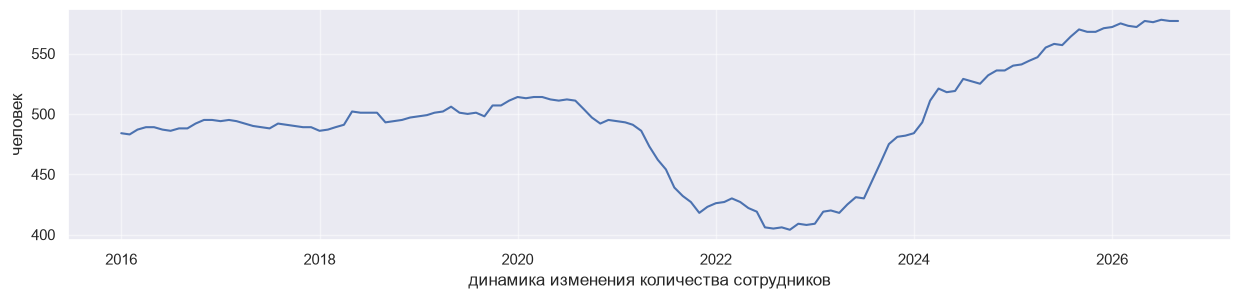

In [117]:
# динамика изменения количества сотрудников
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="qty")
plt.xlabel("динамика изменения количества сотрудников")
plt.ylabel("человек")
plt.show()

Из графика видно, что количество сотрудников резко уменьшилось в кеонце 2021 года и начало восстанавливаться в конце 2023 года. Скорее всего это связано с обстановкой в стране. Также видно, что начиная с конца 2023 года произошел активный рост количества сотрудников

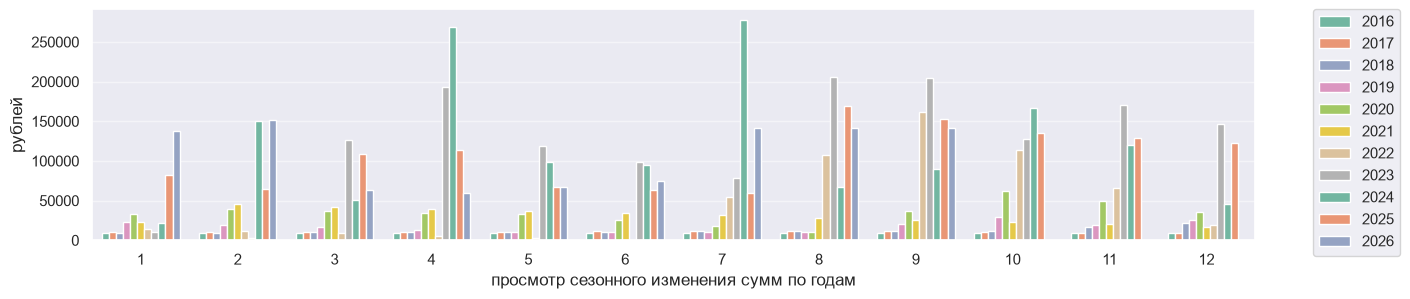

In [118]:
# просмотр сезонного изменения сумм по годам
plt.figure(figsize = (15,3))
sns.barplot(data=dataMonitor.sort_values("year"), x="month", y="sum", hue="year", palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlabel("просмотр сезонного изменения сумм по годам")
plt.ylabel("рублей")
plt.show()

Данный график показывает сезонную зависимость приобретения мониторов, из него можно сделать вывод, что имеются небольшие сезонные отклонения, их меньше в январе и декабре, и больше в июле-октябре, а также в феврале, но идет стабильный рост после 2024 года.

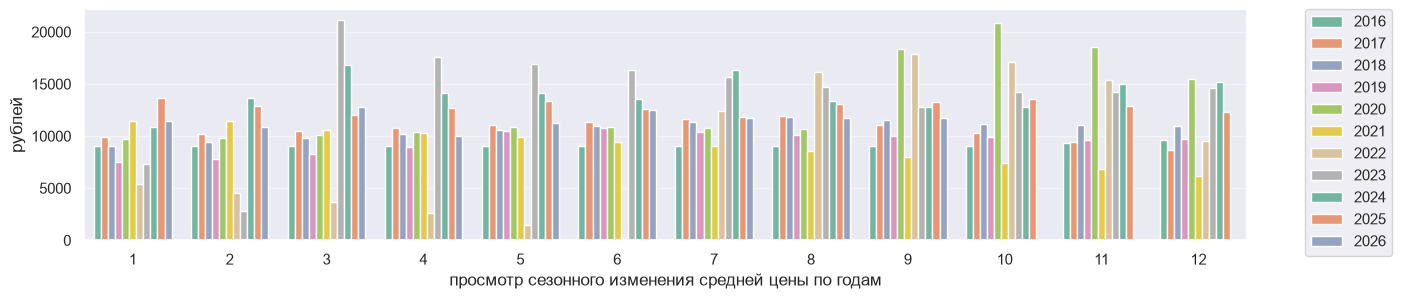

In [119]:
# просмотр сезонного изменения средней цены по годам
plt.figure(figsize = (15,3))
sns.barplot(data=dataMonitor, x="month", y="avg_price", hue="year", palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlabel("просмотр сезонного изменения средней цены по годам")
plt.ylabel("рублей")
plt.show()


Из графика видно, что средняя цена имеет небольшую сезонную зависимость, начиная с 2023 года, видимо это связано с курсом валюты.

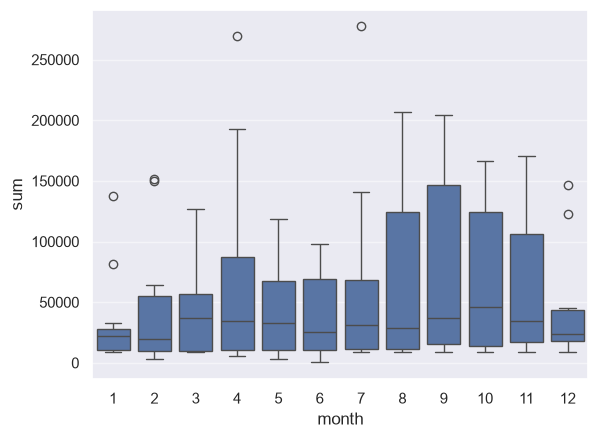

In [120]:
sns.boxplot(data =dataMonitor, x="month", y = "sum")
plt.show()

Из графика видно, что имеется сезонная зависимость по сумме покупок. В январе, апреле, ноябре хоть суммы и не большие, но более прогнозируемые, чем в другие месяца. В Феврале, марте, июле, августе, сентябре и декабре сложнее всего предсказать, т.к. идет большой разброс. Также имеются выбросы, скорее всего связанные с массовым приобритением (по ним можно судить, что в апреле, октябре и ноябре появлялась возможность приобрести мониторы в больших количествах, скорее всего это связано с финансовыми возможностями компаниями в тот момент)

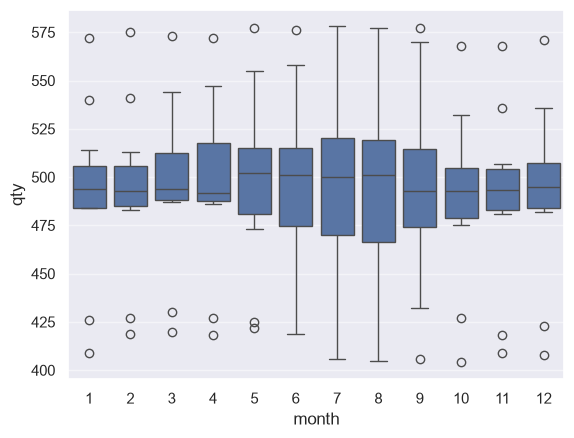

In [121]:
sns.boxplot(data =dataMonitor, x="month", y = "qty")
plt.show()

Данный график показывает стабильный средний состав сотрудников компании, но в январе, феврале и ноябре количество сотрудников более прогнозируемо, чем в летние месяцы. Бывают выбросы, скорее всего связанные с обстановкой в стране.

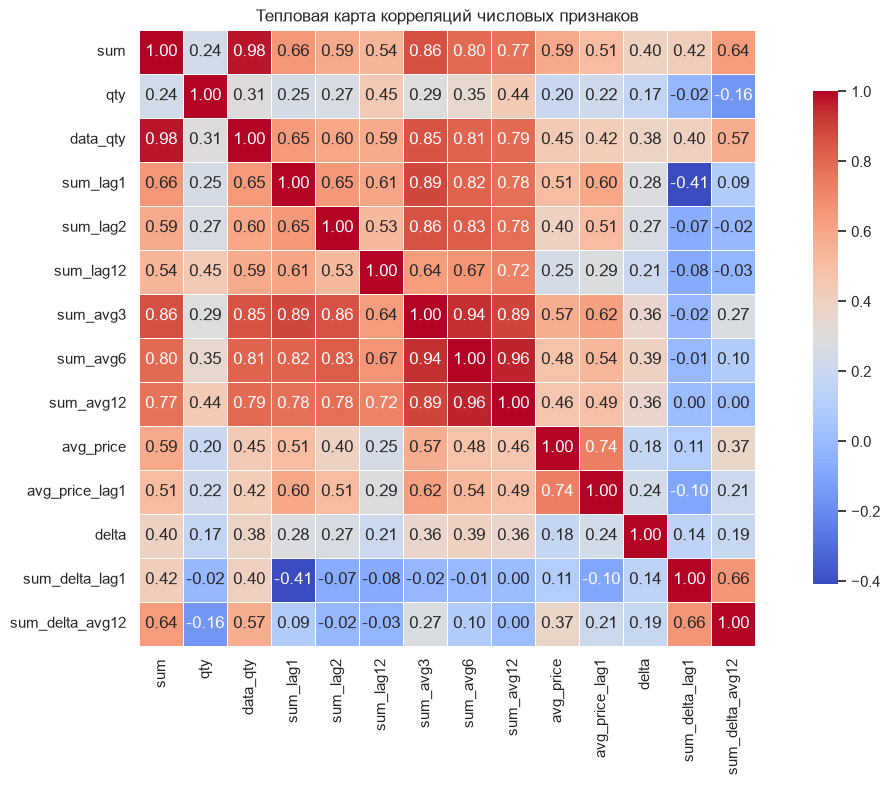

In [122]:
# Попытка выбобра числовых характеристик с помощью тепловой карты
numeric_cols = ['sum', 'qty', 'data_qty', 'sum_lag1', 'sum_lag2', 'sum_lag12',
                'sum_avg3', 'sum_avg6', 'sum_avg12', 'avg_price', 'avg_price_lag1',
                'delta', 'sum_delta_lag1', 'sum_delta_avg12']
df_numeric = dataMonitor[numeric_cols]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(15, 8))  # размер графика
sns.heatmap(corr_matrix,
            annot=True,        # показывать значения коэффициентов в ячейках
            fmt='.2f',         # формат чисел (2 знака после запятой)
            cmap='coolwarm',   # цветовая схема: синий – отрицательная, красный – положительная
            square=True,       # квадратные ячейки
            linewidths=0.5,    # линии между ячейками
            cbar_kws={"shrink": 0.8})  # настройка цветовой шкалы
plt.title('Тепловая карта корреляций числовых признаков')
plt.show()


Из графика видно:
* qty (количество сотрудников) - имеет слабую корреляцию, но нужна для уточнения суммы
* data_qty (количество единиц товаров) - сильно коррелирует с sum, удалим его
* sum_lag1, sum_lag2, sum_lag12, sum_avg3, sum_avg6, sum_avg12 также имеют ссильную корреляцию, оставим только один sum_avg12 - это средняя за год, она будет показывать средний показатель
* avg_price и avg_price_lag1 такде имеют сильную корреляцию, оставим только один, avg_price - он поможет с уточнением суммы
* delta - имеет слабую корреляцию, поможет указать тренд
* um_delta_lag1 и sum_delta_avg12 - имеют сильную корреляцию, оставим только один sum_delta_avg12, он показывает тренд, это поможет для прогнозирования.

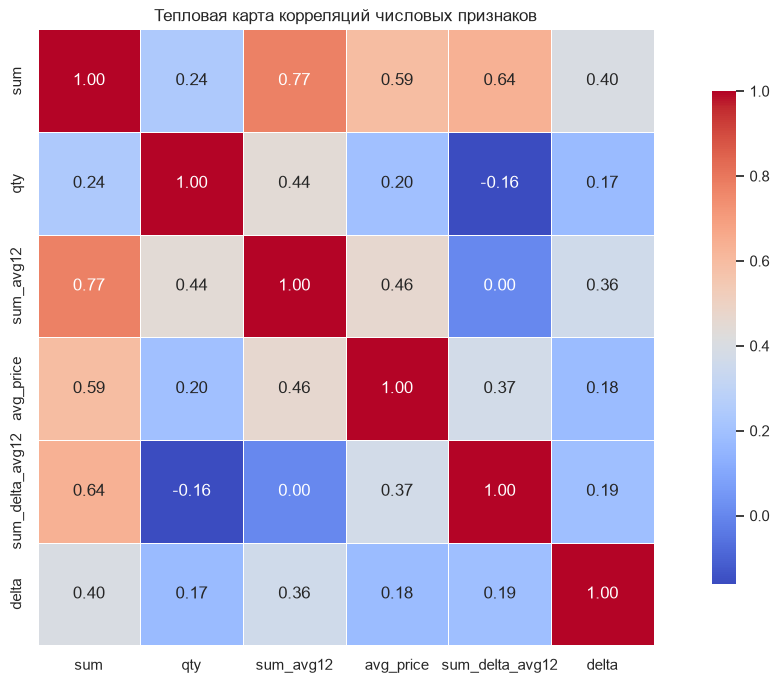

In [123]:
numeric_cols = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']
df_numeric = dataMonitor[numeric_cols]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(15, 8))  # размер графика
sns.heatmap(corr_matrix,
            annot=True,        # показывать значения коэффициентов в ячейках
            fmt='.2f',         # формат чисел (2 знака после запятой)
            cmap='coolwarm',   # цветовая схема: синий – отрицательная, красный – положительная
            square=True,       # квадратные ячейки
            linewidths=0.5,    # линии между ячейками
            cbar_kws={"shrink": 0.8})  # настройка цветовой шкалы
plt.title('Тепловая карта корреляций числовых признаков')
plt.show()


По графику видно, что выбранные 5 признаков имеют между собой слабую корреляцию, а значит с помощью их можно более точнее обучить модель для прогнозирования.

In [124]:
print("\nКорреляция по количеству сотрудников")
print(corr_matrix['qty'].sort_values(ascending=False))

print("\nКорреляция по средней цене за поледний год")
print(corr_matrix['sum_avg12'].sort_values(ascending=False))

print("\nКорреляция по средней цене")
print(corr_matrix['avg_price'].sort_values(ascending=False))

print("\nКорреляция по отклонению от средней суммы за год")
print(corr_matrix['sum_delta_avg12'].sort_values(ascending=False))

print("\nКорреляция по отклонению количества сотрудников")
print(corr_matrix['delta'].sort_values(ascending=False))


Корреляция по количеству сотрудников
qty                1.000000
sum_avg12          0.442731
sum                0.239322
avg_price          0.195687
delta              0.171598
sum_delta_avg12   -0.160817
Name: qty, dtype: float64

Корреляция по средней цене за поледний год
sum_avg12          1.000000
sum                0.773625
avg_price          0.463339
qty                0.442731
delta              0.362124
sum_delta_avg12    0.004578
Name: sum_avg12, dtype: float64

Корреляция по средней цене
avg_price          1.000000
sum                0.592765
sum_avg12          0.463339
sum_delta_avg12    0.371905
qty                0.195687
delta              0.178944
Name: avg_price, dtype: float64

Корреляция по отклонению от средней суммы за год
sum_delta_avg12    1.000000
sum                0.637179
avg_price          0.371905
delta              0.188670
sum_avg12          0.004578
qty               -0.160817
Name: sum_delta_avg12, dtype: float64

Корреляция по отклонению количества сот

## Гиптотезы

### По признаку qty

Гипотеза: При сохранение количества сотрудников новые мониторы потребуются только для замены испорченных.

Описание: При сохранении количества сотрудников, компании не требуется подготавливать новые рабочие места (приобретать компьютеры, мониторы и т.д.) или при увольнении одного сотрудника его место занимает другой, при этом рабочее место сохраняется. Исключением может быть выход из строя монитора из-за состаривания или при возникновении нестандартной ситуации (пожар, уронили, облили водой, скачен напряжения и т.д.)

Практически: смысл этой гипотезы в том, что при соблюдении определенной численности сотрудников, ИТ отделу не потребуется приобретения мониторов, только в случае замены старых.


### По признаку sum_avg12

Гипотеза: сумма бюджета на месяц зависит от среднего уровня покупок за прошлый год.

Описание: Бюджетирование в компании зачастую происходит на основе исторических данных.

Практически: Поможет формировать бюджет на основе предыдущих данных за прошлый год.

### По признаку avg_price

Гипотеза: Средняя цена монитора положительно влияет на общую сумму бюджета.

Описание: При фиксированной средней цене, увеличение количества мониторов приведет к увеличению суммы. Сильное уменьшение средней цены скорее всего приведет к увеличению количества мониторов, но сохранит общую сумму.

Практически: Позволит планировать сумму бюджета более точно, при небольшом изменении средней цены. При резком снижении или увеличении поможет сбалансировать бюджет по количеству.

### По признаку sum_delta_avg12

Гипотеза: Если отклонение от среднего за год положительное, то сумма бюджета будет увеличение суммы бюджета.

Описание: Отклонение от среднего показывает текущий тренд - если компания увеличивает покупки, то скорее всего это будет продолжаться дальше.

Практически: Позволит планировать бюджет на более длительные сроки.

### По признаку delta

Гипотеза: Дельта количества сотрудников положительно влияет на сумму бюджета

Описание: Увеличение количества работников повышает потребность в новых мониторов.

Практически: Если будет известно, что планируется увеличить штат сотрудников, то можно будет заранее внести в бюджет соответствующие траты на формирование рабочего места сотрудника.

# Домашнее задание

In [125]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [126]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

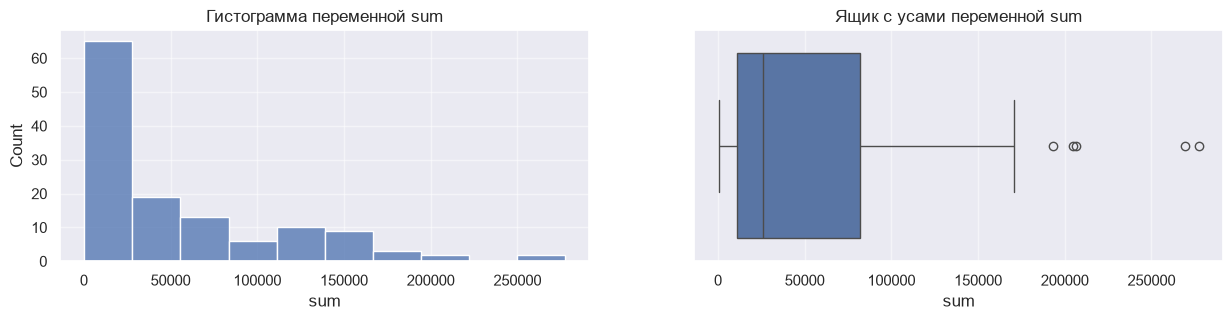

In [127]:
visualize_distribution(dataMonitor, variable="sum")
# 1. Подготовка данных

## 1. Подготовка данных

In [128]:
# Убираем выбросы по правилу +/- 2 стандартных отклонения, z-score
numeric_cols = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']
df = dataMonitor[numeric_cols]
df = df[np.abs((dataMonitor['sum']-dataMonitor['sum'].mean())/dataMonitor['sum'].std())<=2]
print(dataMonitor.shape)
print(df.shape)

(129, 20)
(124, 6)


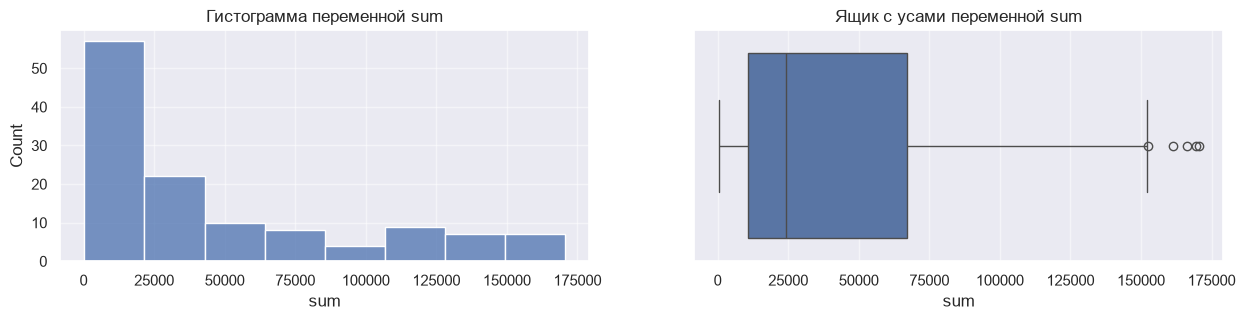

In [129]:
visualize_distribution(df, variable = "sum")

In [130]:
df.head()

,sum,qty,sum_avg12,avg_price,sum_delta_avg12,delta
0,9016.95,484,9016.95,9016.95,0.0,0.0
1,9016.95,483,9016.95,9016.95,0.0,-1.0
2,9016.95,487,9016.95,9016.95,0.0,4.0
3,9016.95,489,9016.95,9016.95,0.0,2.0
4,9016.95,489,9016.95,9016.95,0.0,0.0


Sum - Целевая переменная

## 2. Изучаем связь целевой переменной и предикторов

<Figure size 1500x1500 with 0 Axes>

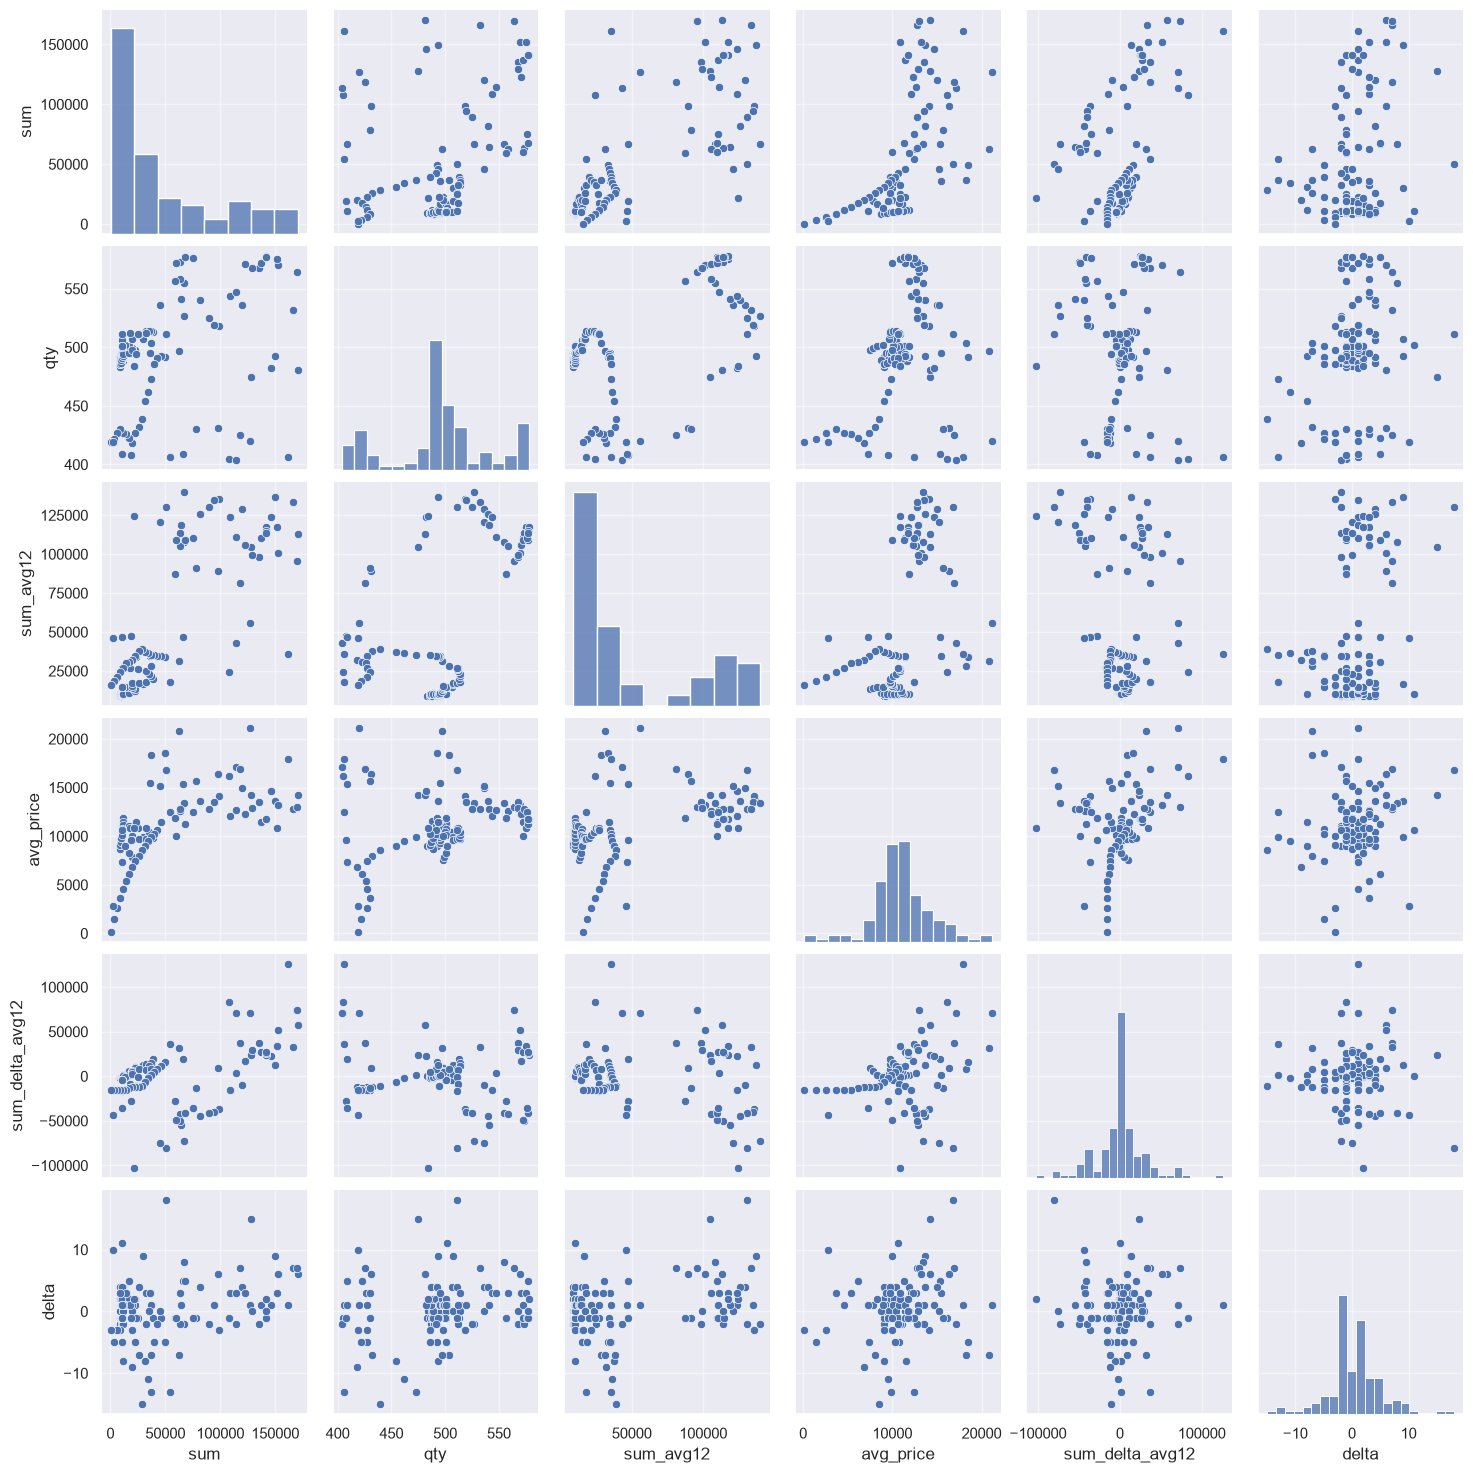

In [131]:
fig = plt.figure(figsize = (15, 15))
sns.pairplot(df)
plt.show()

## 3. Обучим модели линейной регрессии

In [132]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test):
    return model.predict(X_test)

def visualize_prediction(y_true, y_pred):
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
    sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
    ax.set_title("Истинные и предсказанные значения y")
    ax.set_xlabel('true y')
    ax.set_ylabel('pred y')
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
    print('MSE: ', mean_squared_error(y_true, y_pred)),
    print('RMSE: ', root_mean_squared_error(y_true, y_pred))
    print('MAE: ', mean_absolute_error(y_true, y_pred))
    print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
    print('R2: ', r2_score(y_true, y_pred))

#### Простая модель $sum_i = w_0 + w_1 \cdot qty_i$

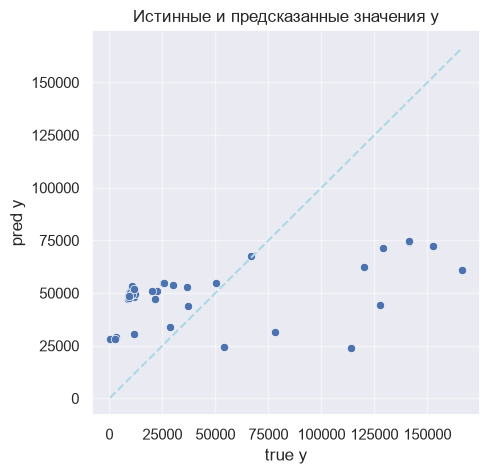

Среднее значение Y:  43167.41062833914
Среднеквадратическое отклонение Y:  49309.910042538744
MSE:  2045383017.4987018
RMSE:  45225.91090844608
MAE:  39452.75528478568
MAPE:  4.584890854914964
R2:  0.15878651638587038


In [133]:
target_col = ['sum']
features_col = ['qty']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Простая модель $sum_i = w_0 + w_1 \cdot qty_i + w_2 \cdot sum_avg12_i$

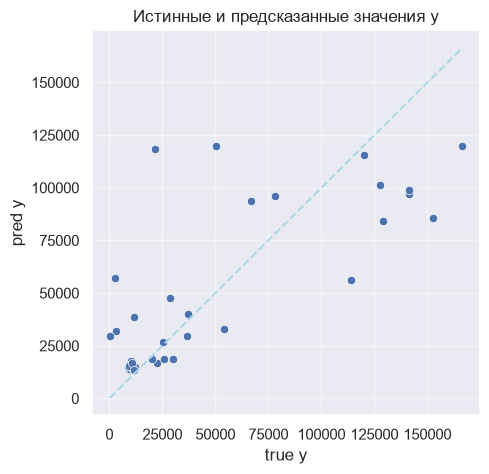

Среднее значение Y:  43167.41062833914
Среднеквадратическое отклонение Y:  49309.910042538744
MSE:  938350062.9382802
RMSE:  30632.500109169676
MAE:  20379.6130510686
MAPE:  3.6038918001803393
R2:  0.614080727892643


In [134]:
target_col = ['sum']
features_col = ['qty', 'sum_avg12']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Простая модель $sum_i = w_0 + w_1 \cdot qty_i + w_2 \cdot sum_avg12_i + w_3 \cdot sum_avg_pice_i$

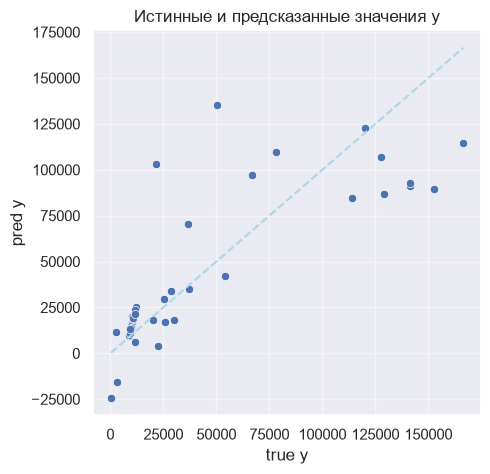

Среднее значение Y:  43167.41062833914
Среднеквадратическое отклонение Y:  49309.910042538744
MSE:  832050749.9947109
RMSE:  28845.289910047897
MAE:  19312.068310484152
MAPE:  2.741638197731793
R2:  0.6577989041862942


In [135]:
target_col = ['sum']
features_col = ['qty', 'sum_avg12', 'avg_price']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Простая модель $sum_i = w_0 + w_1 \cdot qty_i + w_2 \cdot sum\_avg12_i + w_3 \cdot sum\_avg\_pice_i + w_4 \cdot sum\_delta\_avg12_i$

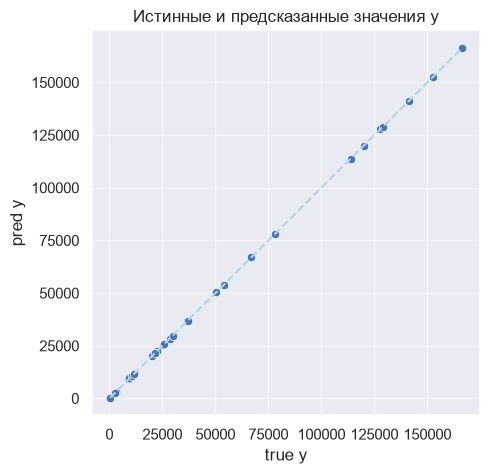

Среднее значение Y:  43167.41062833914
Среднеквадратическое отклонение Y:  49309.910042538744
MSE:  8.419793906994842e-22
RMSE:  2.9016881133221127e-11
MAE:  2.095997088628526e-11
MAPE:  2.4954299951932323e-15
R2:  1.0


In [136]:
target_col = ['sum']
features_col = ['qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

#### Простая модель $sum_i = w_0 + w_1 \cdot qty_i + w_2 \cdot sum\_avg12_i + w_3 \cdot sum\_avg\_pice_i + w_4 \cdot sum\_delta\_avg12_i + w_5 \cdot delta_i$

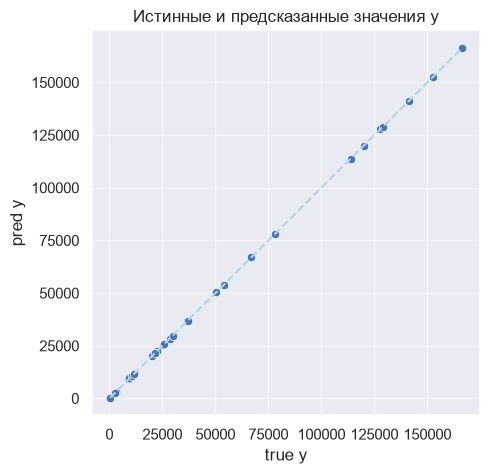

Среднее значение Y:  43167.41062833914
Среднеквадратическое отклонение Y:  49309.910042538744
MSE:  2.189661197045907e-22
RMSE:  1.4797503833572427e-11
MAE:  1.2868795460146828e-11
MAPE:  1.746177909521387e-15
R2:  1.0


In [151]:
target_col = ['sum']
features_col = ['qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

## 4. Интерпретируем полученную модель

In [138]:
w0 = model.intercept_   # Забираем intercept
weights = model.coef_   # Забираем веса модели
features = model.feature_names_in_
pd.Series(dict(zip(features.tolist()+['intercept'], weights[0].tolist()+[w0[0]])))

qty                2.081635e-13
sum_avg12          1.000000e+00
avg_price          6.800116e-16
sum_delta_avg12    1.000000e+00
delta              3.107247e-13
intercept         -9.458745e-11
dtype: float64

## ??? $\hat{sum}_i = 13.7035 - 0.4223 \cdot lstat_i + 2.5140 \cdot rm_i - 0.1193 \cdot crim_i - 0.1903 \cdot indus_i$

In [139]:
def draw_scatteplot(df, x, y, xlab, ylab, y_pred = None):
    data = df.copy()
    plt.figure(figsize = (15,5))
    sns.scatterplot(x = x, y = y, data = data)
    if y_pred is not None:
        data["y_pred"] = y_pred
        sns.lineplot(x = x, y = "y_pred", data = data, c = 'forestgreen')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

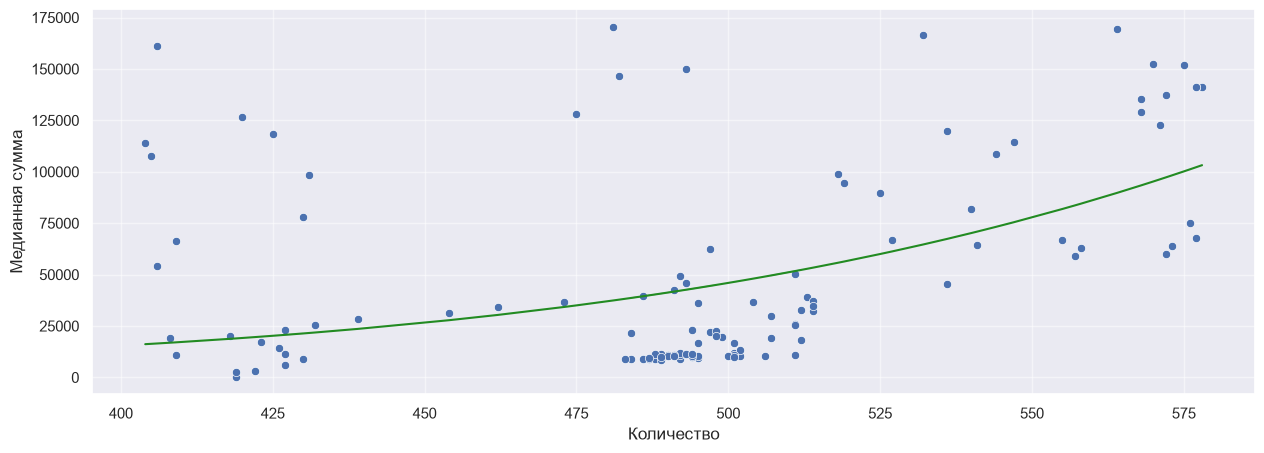

In [140]:
df["qty6"] = df["qty"]**6 # Трансформируем переменную
target_col = ['sum']
features_col = ['qty6']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "qty", y = "sum", xlab = "Количество", ylab = "Медианная сумма", y_pred = y_pred)

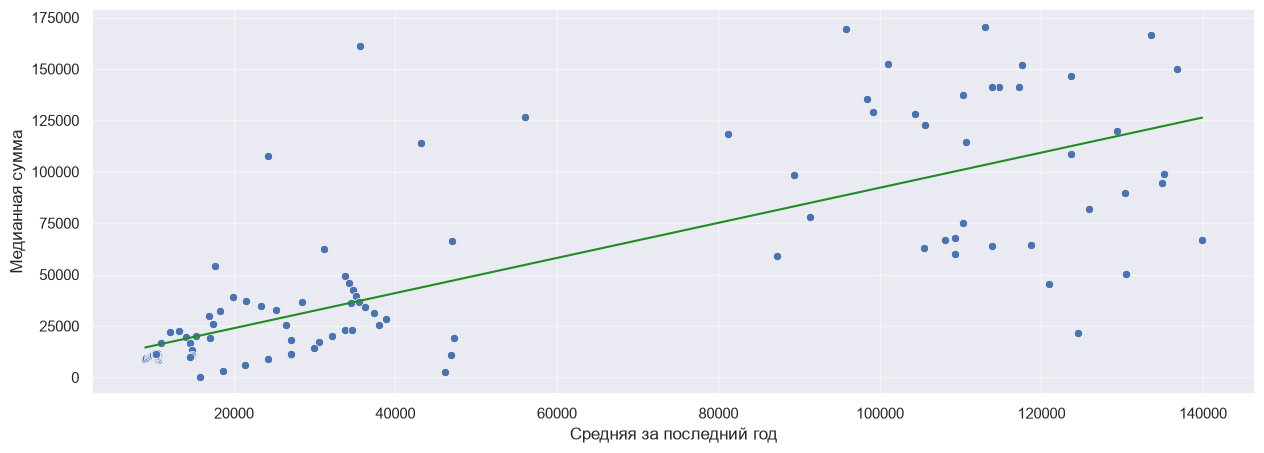

In [141]:
#df["qty6"] = df["qty"]**6 # Трансформируем переменную
target_col = ['sum']
features_col = ['sum_avg12']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "sum_avg12", y = "sum", xlab = "Средняя за последний год", ylab = "Медианная сумма", y_pred = y_pred)

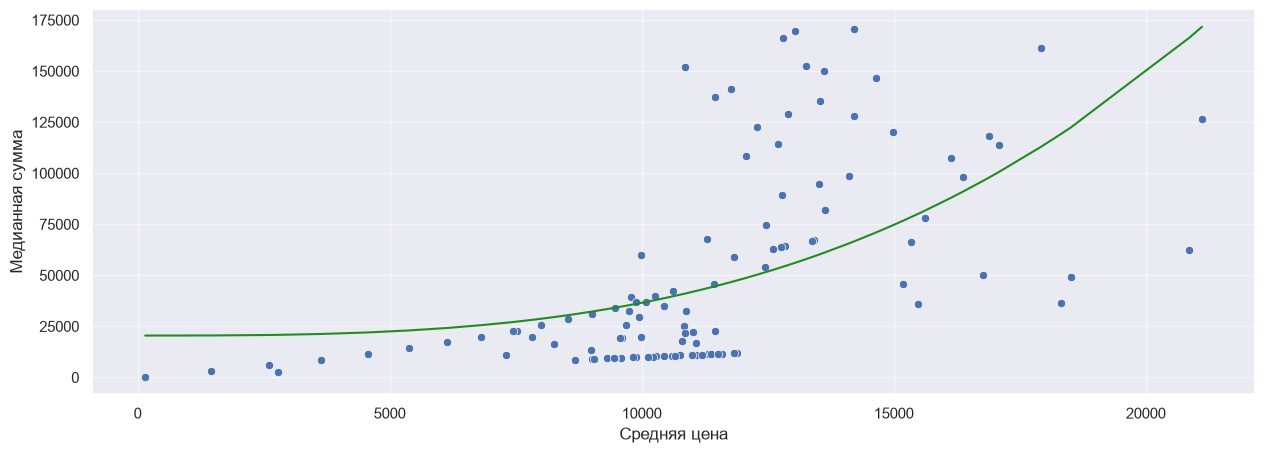

In [142]:
df["avg_price3"] = df["avg_price"]**3 # Трансформируем переменную
target_col = ['sum']
features_col = ['avg_price3']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "avg_price", y = "sum", xlab = "Средняя цена", ylab = "Медианная сумма", y_pred = y_pred)

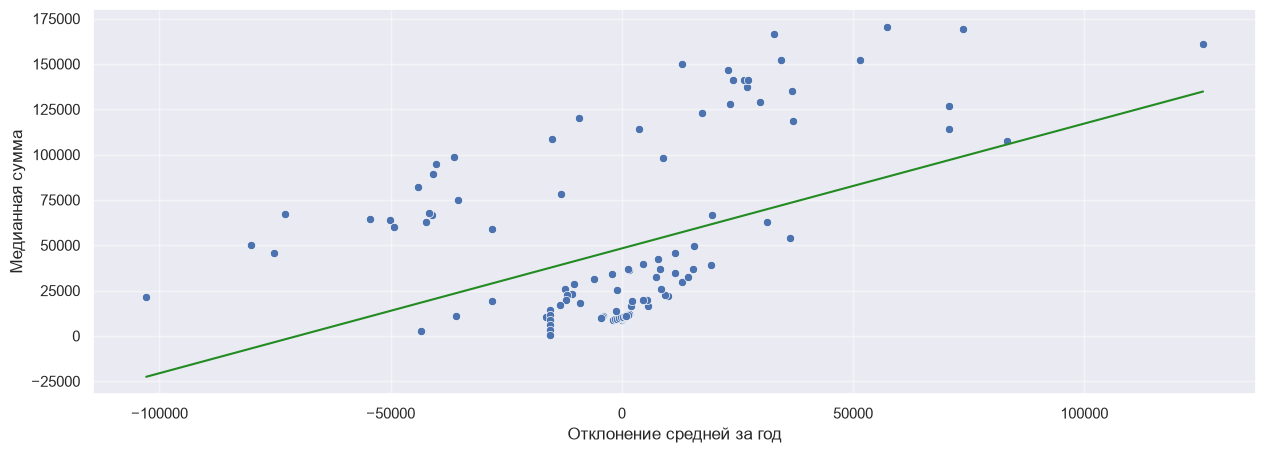

In [143]:
target_col = ['sum']
features_col = ['sum_delta_avg12']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "sum_delta_avg12", y = "sum", xlab = "Отклонение средней за год", ylab = "Медианная сумма", y_pred = y_pred)

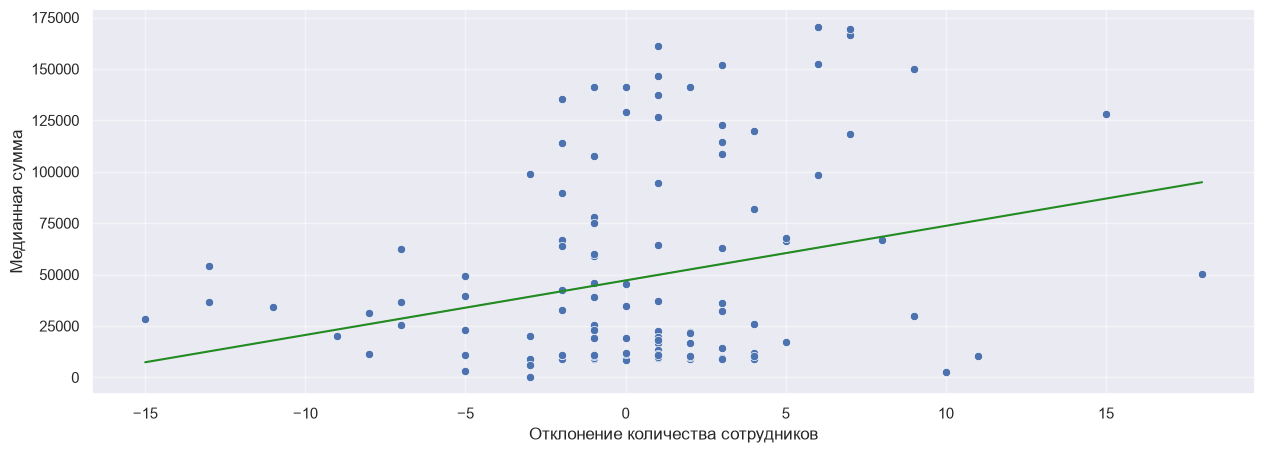

In [144]:
target_col = ['sum']
features_col = ['delta']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "delta", y = "sum", xlab = "Отклонение количества сотрудников", ylab = "Медианная сумма", y_pred = y_pred)

## 7. Еще одна версия модели

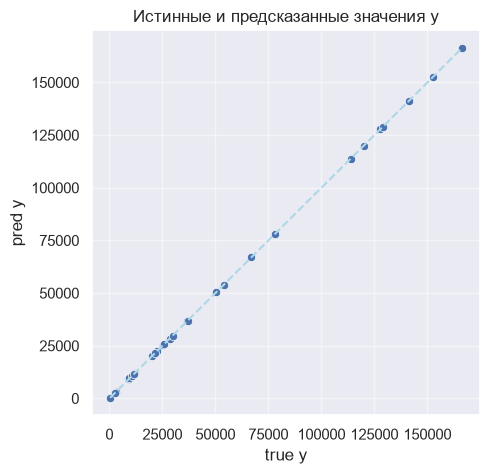

Среднее значение Y:  43167.41062833914
Среднеквадратическое отклонение Y:  49309.910042538744
MSE:  5.106730649985911e-22
RMSE:  2.2598076577412317e-11
MAE:  2.0230711415046597e-11
MAPE:  2.1285197613536523e-15
R2:  1.0


In [145]:
target_col = ['sum']
features_col = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

## 8. Проверим устойчивость модели на разных выборках

In [146]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

target_col = ['sum']
features_col = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']

for random_state in range(0, 20, 2):
  X_train, X_test, y_train, y_test = train_test_split(df[features_col], df[target_col], test_size = 0.33, random_state = random_state)

  reg = LinearRegression()
  reg.fit(X_train, y_train)
  y_pred = reg.predict(X_test)

  df1 = pd.DataFrame(
      {
          'MSE'  : mean_squared_error(y_test, y_pred),
          'RMSE' : root_mean_squared_error(y_test, y_pred),
          'MAE'  : mean_absolute_error(y_test, y_pred),
          'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
          'R2'   : r2_score(y_test, y_pred)
      },
      index = [random_state]
  )

  df2 = pd.DataFrame(
      index = X_train.columns,
      data = reg.coef_[0],
      columns = [random_state]
  )

  metrics_df = pd.concat([metrics_df, df1])
  coefs_df = pd.concat([coefs_df, df2], axis = 1)

In [147]:
metrics_df

,MSE,RMSE,MAE,MAPE,R2
0,1.569020e-22,1.252605e-11,8.007990e-12,3.718531e-16,1.0
2,2.237019e-22,1.495667e-11,1.339841e-11,2.568691e-15,1.0
4,8.700528e-22,2.949666e-11,2.628662e-11,1.502976e-15,1.0
6,8.053108e-22,2.837800e-11,2.107366e-11,9.461630e-16,1.0
8,1.874553e-21,4.329610e-11,3.416151e-11,1.791979e-15,1.0
10,3.945450e-22,1.986316e-11,1.459628e-11,6.054422e-16,1.0
12,1.545617e-22,1.243229e-11,9.338958e-12,8.108434e-16,1.0
14,2.220415e-21,4.712128e-11,4.132655e-11,2.499390e-15,1.0
16,5.969420e-22,2.443240e-11,2.222716e-11,1.143266e-15,1.0
18,2.165397e-22,1.471529e-11,1.022627e-11,4.402376e-16,1.0


In [148]:
coefs_df.T

,sum,qty,sum_avg12,avg_price,sum_delta_avg12,delta
0,0.666667,2.331468e-14,0.333333,1.387779e-16,0.333333,-4.913267e-14
2,0.666667,-8.726353e-14,0.333333,1.040834e-17,0.333333,-6.191719e-13
4,0.666667,-8.143486e-14,0.333333,1.020017e-15,0.333333,3.334560e-13
6,0.666667,6.833423e-14,0.333333,-6.245005e-17,0.333333,-2.278361e-14
8,0.666667,-2.720046e-14,0.333333,5.065393e-16,0.333333,-2.851566e-14
10,0.666667,-9.436896e-15,0.333333,6.383782e-16,0.333333,-1.116003e-13
12,0.666667,3.780309e-14,0.333333,-1.387779e-17,0.333333,1.045338e-14
14,0.666667,3.758105e-14,0.333333,-1.838807e-16,0.333333,-2.796374e-15
16,0.666667,1.456057e-13,0.333333,3.469447e-18,0.333333,-1.800146e-13
18,0.666667,-1.443290e-15,0.333333,3.816392e-17,0.333333,5.841280e-14


## 9. Variance inflation factor

In [149]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

target_col = ['sum']
features_col = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']

#X = df[features_col]
#y = df[target_col]
X = dataMonitor[features_col]
y = dataMonitor[target_col]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data.sort_values(by = 'VIF', ascending = False).reset_index(drop = True)

C:\Users\Burtsev-D\AppData\Local\Temp\ipykernel_3364\1385941937.py:13: UserWarning: The design matrix is poorly conditioned (condition number=7.16e+15). VIF calculations may be numerically unstable.
  vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
D:\ИИ\git\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
D:\ИИ\git\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
D:\ИИ\git\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


,feature,VIF
0,sum,1.000800e+15
1,sum_avg12,1.000800e+15
2,sum_delta_avg12,1.000800e+15
3,avg_price,1.560490e+00
4,qty,1.297163e+00
5,delta,1.210744e+00
